Внимательно прочтите эти инструкции. Выполнение **всех** этих пунктов - обязательно для получения баллов за задание.

1) Проверка
    - После того, как вы допишете код
        - очистите все клетки (`Cell > All Output > Clear`)
        - выполните все клетки подряд (`Cell > Run All`)
    - Выполнение должно пройти без ошибок
    - Сохраните ноутбук с выполненными клетками

<!-- -->

2) Отправка в тестовую систему
    - Когда вы готовы сдать ноутбук, загрузите его в тестовую систему (fall.cv-gml.ru)
    - В тестовую систему нужно загружать только сам `.ipynb` ноутбук
        - Не нужно его `zip`овать
        - Не нужно его конвертировать в `pdf` или `html`
    - После загрузки в тестовую систему там появится ссылка для просмотра загруженного решения
        - Проверьте, что вы загрузили в тестовую систему то, что хотели
        - Проверьте, что в системе отображаются результаты выполнения всех клеток

## Дифференцируемая растеризация

Необходимо реализовать процедуру оптимизации текстуры из входных изображений с позами камер, считая что сэмплированная текстура и есть результат шейдинга. Код загрузки данных вам предоставлен, рекомендуется внимательно его изучить. Вам необходимо имплементировать процедуру рендеринга текстурированного меша используя примитивы [nvdiffrast](https://nvlabs.github.io/nvdiffrast/).

Работы оцениваются по бинарному принципу (зачет/незачет).

In [ ]:
%%bash

# Download dataset and helper library
for part in data lib; do
    if [ ! -d "${part}/" ]; then
        curl -sO "https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/differentiable-rasterization/${part}.zip"
        unzip -qo "${part}.zip"
    fi
done

# Install required dependencies
if ! pip freeze | grep -q nvdiffrast; then
    pip install -q \
        git+https://github.com/NVlabs/nvdiffrast.git \
        ninja xatlas trimesh \
        torch matplotlib
fi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.9/708.9 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import matplotlib.pyplot as plt
import nvdiffrast.torch as dr
import torch
import torch.nn.functional as Func

glctx = dr.RasterizeCudaContext()

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [ ]:
from lib.dataset import DatasetNERF

dataset = DatasetNERF(cfg="./data/hotdog/transforms_train.json", resolution=(400, 400))

In [ ]:
VERBOSE = False

def render_textured(
    mesh, # (num_verts, 3)
    mvp, # (1, 4, 4)
    resolution=(800, 800),
    texture=None,
    enable_mip=True,
    max_mip_level=9,
):

    # === Vertex Processing ===
    verts_homo = torch.cat([mesh.verts.cuda(), torch.ones_like(mesh.verts[:, :1]).cuda()], dim=1)  # (N_v, 4)
    mvp = mvp.cuda()  # (1, 4, 4) - already has batch dimension

    # === Projection ===
    verts_pos = (verts_homo @ mvp[0].T).unsqueeze(0).contiguous()  # (1, N_v, 4)

    # === Rasterization ===
    faces = mesh.faces.int().cuda().contiguous()   # (N_f, 3)
    rast_out, _ = dr.rasterize(glctx, verts_pos, faces, resolution=resolution) # (1, H, W, 4) <--> (u, v, z/w, triangle_id)

    # === Interpolate UV ===
    uvs = mesh.uvs.cuda().unsqueeze(0).contiguous()  # (1, N_v, 2)
    uv_image, _ = dr.interpolate(uvs, rast_out, faces)  # (1, H, W, 2) ,  (image-space derivatives)


    if VERBOSE:
      print('verts_homo :', verts_homo.shape)
      print('mvp :', mvp.shape)
      print('verts_pos :', verts_pos.shape)
      print('faces :', faces.shape)
      print("rast_out :", rast_out.shape)
      print("uvs : ", uvs.shape)
      print("uv_image : ", uv_image.shape)

    # === Mask ===
    mask = (rast_out[..., 3:] > 0).float()  # (1, H, W, 1)

    # === If texture is None, return UV + mask
    if texture is None:
        uv_image_vis = torch.cat([uv_image, torch.zeros_like(uv_image[..., :1])], dim=-1)
        return uv_image_vis, mask # (1, H, W, 2)
    else:
        if VERBOSE:
          print('texture :', texture.shape)
        texture = texture.unsqueeze(0) if texture is not None else None
        resolution = torch.tensor(resolution)
        if VERBOSE:
          print('texture after unsqueezing:', texture.shape)

    # === Texture Sampling ===


    color = dr.texture(
        texture,
        uv_image,
        max_mip_level=max_mip_level,
    )

    # === Antialiasing ===
    color = dr.antialias(
        color.contiguous(),
        rast_out.contiguous(),
        verts_pos,
        faces
    )

    return color, mask

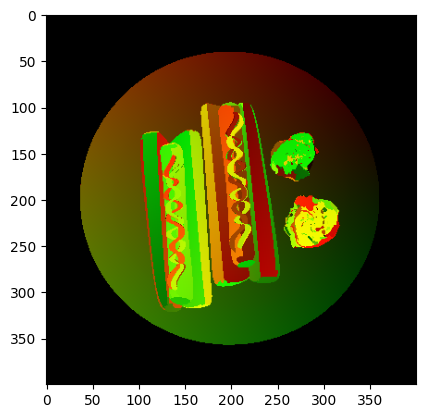

In [ ]:
c, _ = render_textured(
    dataset.mesh,
    dataset[0]["mvp"],
    dataset.resolution,
)
plt.imshow(c[0].detach().cpu());

Ожидаемый результат:

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/differentiable-rasterization/ref_notexture.png" style="display: inline-block; text-align: left;"/>

In [ ]:
texture = torch.full([512, 512, 3], 0.5, device="cuda", requires_grad=True)
optimizer = torch.optim.Adam([texture], lr=1e-3)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import trange
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=1, num_workers=4, pin_memory=True)

num_steps = 1000
pbar = trange(num_steps)

for step in pbar:
    total_loss = 0.0
    optimizer.zero_grad()

    for frame in train_loader:
        mvp = frame["mvp"]
        target = frame["img"].cuda()  # (H, W, 3)

        # === Rendering ===
        color_pred, mask = render_textured(
            mesh=dataset.mesh,
            mvp=mvp.squeeze(0),
            resolution=dataset.resolution,
            texture=texture
        )  # color_pred: (1, H, W, 3), mask: (1, H, W, 1)

        # === Loss ===
        loss = F.mse_loss(color_pred * mask, target * mask)
        loss.backward()
        total_loss += loss.item()

    optimizer.step()
    pbar.set_description(f"Step {step} | Loss: {total_loss:.6f}")

    # === Visualization ===
    if step % 100 == 0 and VERBOSE:
        with torch.no_grad():
            img = color_pred[0].detach().cpu().clamp(0, 1)
            plt.imshow(img)
            plt.title(f"Step {step}")
            plt.axis('off')
            plt.show()

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
  0%|          | 0/1000 [00:00<?, ?it/s]<ipython-input-7-f65ea32350a6>:29: UserWarning: Using a target size (torch.Size([1, 1, 400, 400, 3])) that is different to the input size (torch.Size([1, 400, 400, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(color_pred * mask, target * mask)
Step 999 | Loss: 0.055118: 100%|██████████| 1000/1000 [16:41<00:00,  1.00s/it]


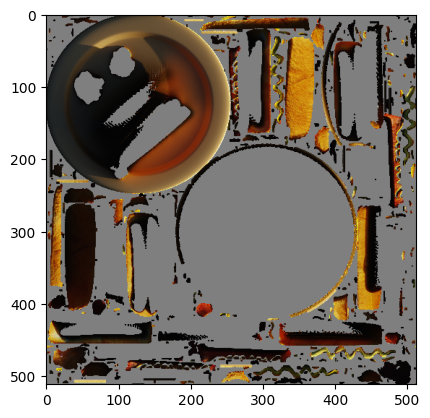

In [ ]:
plt.imshow(texture.detach().cpu());

Ожидаемый результат:

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/differentiable-rasterization/ref_texture.png" style="display: inline-block; text-align: left;"/>

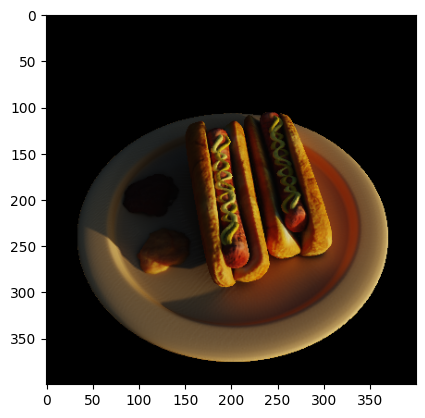

In [ ]:
c, mask = render_textured(
    dataset.mesh,
    dataset[90]["mvp"],
    dataset.resolution,
    texture=texture,
)
c = c * mask
plt.imshow(c[0].detach().cpu());

Ожидаемый результат:

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/differentiable-rasterization/ref_render.png" style="display: inline-block; text-align: left;"/>